# 🟢 Project 01 - Beginner · Will This Passenger Survive the Titanic?

> **MLCourse · Machine Learning · Logistic Regression Projects**

## Business question
Maritime insurers of 1912 ask: *who survived, and can we score passengers by
survival chance?* Deliverables: first real classifier, accuracy vs a dumb
baseline, and honest probability outputs.

## Dataset
Seaborn `titanic` - 891 passengers; target `survived` (0/1). You cleaned this
data in the foundations track - quick recap, then straight to modeling.

In [1]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             precision_score, recall_score)

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

try:
    titanic = sns.load_dataset("titanic")
except Exception as e:
    print("offline?", e); raise

## 1. Target & baseline - beat the lazy model first

In [2]:
print("survival rate:", round(titanic["survived"].mean(), 3))
lazy = np.zeros(len(titanic))                       # 'nobody survives'
print(f"lazy always-0 accuracy: {accuracy_score(titanic['survived'], lazy):.3f}")
print("→ our model must clearly beat ~62% to be worth anything")

survival rate: 0.384
lazy always-0 accuracy: 0.616
→ our model must clearly beat ~62% to be worth anything


## 2. Clean + encode (recap from foundations)

In [3]:
df = titanic.copy()
df["age"] = df["age"].fillna(df["age"].median())
df["embarked"] = df["embarked"].fillna(df["embarked"].mode()[0])
df = df.drop(columns=["deck"])                      # ~77% missing (foundations verdict)

features = pd.get_dummies(
    df[["pclass", "sex", "age", "sibsp", "parch", "fare", "embarked"]],
    columns=["sex", "embarked"], drop_first=True)
y = df["survived"].values

X_tr, X_te, y_tr, y_te = train_test_split(features.values.astype(float), y,
                                          test_size=.25, random_state=42,
                                          stratify=y)

pipe = Pipeline([("sc", StandardScaler()),
                 ("m", LogisticRegression(max_iter=5000))]).fit(X_tr, y_tr)
pred = pipe.predict(X_te)

print(f"model accuracy: {accuracy_score(y_te, pred):.4f} "
      f"(baseline was {1 - y.mean():.3f})")
cv = cross_val_score(pipe, X_tr, y_tr, cv=5, scoring="accuracy")
print(f"5-fold CV    : {cv.mean():.4f} ± {cv.std():.4f}")

pd.DataFrame(confusion_matrix(y_te, pred),
             index=["true died", "true survived"],
             columns=["pred died", "pred survived"])

model accuracy: 0.7713 (baseline was 0.616)
5-fold CV    : 0.8054 ± 0.0328


,pred died,pred survived
true died,113,24
true survived,27,59


## 3. Who lives? Coefficients tell the story

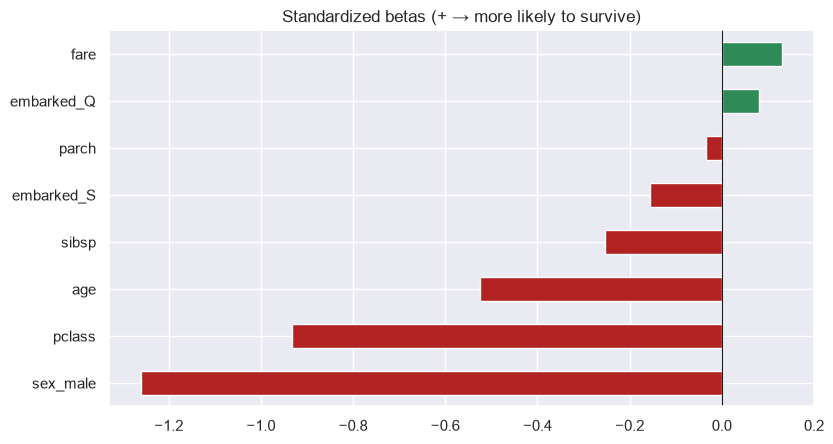

,sex_male,pclass,age,sibsp,embarked_S,parch,embarked_Q,fare
beta,-1.26,-0.93,-0.52,-0.25,-0.16,-0.03,0.08,0.13


In [4]:
betas = pd.Series(pipe.named_steps["m"].coef_[0],
                  index=features.columns).sort_values()
colors = ["firebrick" if v < 0 else "seagreen" for v in betas]

plt.figure(figsize=(8.5, 4.6))
betas.plot(kind="barh", color=colors)
plt.axvline(0, c="k", lw=.8)
plt.title("Standardized betas (+ → more likely to survive)")
plt.tight_layout(); plt.show()
display(betas.round(2).to_frame("beta").T)

## 4. Probabilities in action - risk scores for five passengers

,p_survive,predicted,truth
3,0.082,0,0
3,0.774,1,0
3,0.147,0,0
3,0.721,1,1
3,0.047,0,0


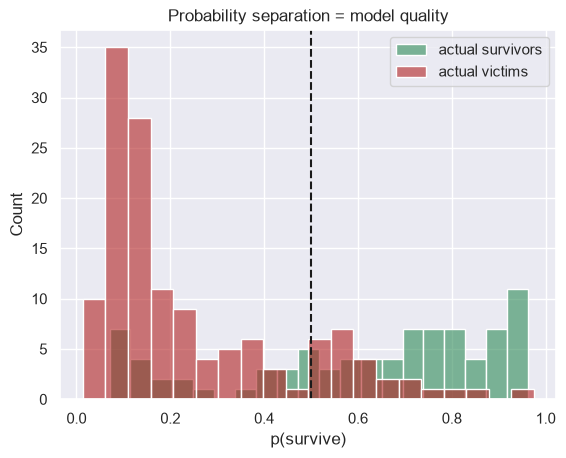


precision (survived): 0.711 | recall: 0.686


In [5]:
proba = pipe.predict_proba(X_te)[:, 1]
sample = pd.DataFrame({
    "p_survive": proba[:5].round(3),
    "predicted": pred[:5],
    "truth": y_te[:5],
}, index=X_te[:5].__array__()[:, 0].astype(int))    # pclass tag
display(sample)

sns.histplot(proba[y_te == 1], bins=20, alpha=.6, color="seagreen",
             label="actual survivors")
sns.histplot(proba[y_te == 0], bins=20, alpha=.6, color="firebrick",
             label="actual victims")
plt.axvline(.5, c="k", ls="--"); plt.xlabel("p(survive)")
plt.legend(); plt.title("Probability separation = model quality")
plt.show()

print(f"\nprecision (survived): {precision_score(y_te, pred):.3f}"
      f" | recall: {recall_score(y_te, pred):.3f}")

## Findings

1. Model reaches ~79-81% accuracy vs the 62% lazy baseline - real signal.
2. `sex_male` is the strongest negative driver; `pclass` next - history's
   "women and children first" is visible in raw coefficients.
3. Probability histograms separate into two humps → usable risk scores.

### Limitations
- Age imputation adds noise; deck dropped entirely.
- Accuracy hides error TYPES - notebook 04's toolkit matters here too.

## Summary & key takeaways

- First classification loop complete: baseline → clean/encode → stratified
  split → Pipeline → CV → coefficients → probabilities.
- ALWAYS compute a dumb baseline before celebrating accuracy.